In [2]:
import numpy as np
import keras
import keras_hub
import tensorflow as tf
import json
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from matplotlib.patches import Rectangle
import random
import math
import torch

C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\gpu\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Quick health check to prove it works:
print("Is PyTorch utilizing the GPU?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

Is PyTorch utilizing the GPU?: True
Device Name: NVIDIA GeForce RTX 5050 Laptop GPU


### Load Datasets

In [4]:
images_path = keras.utils.get_file("coco", "http://images.cocodataset.org/zips/train2017.zip", extract=True)
annotations_path = keras.utils.get_file("annotations", "http://images.cocodataset.org/annotations/annotations_trainval2017.zip", extract=True)


In [5]:
images_path, annotations_path

('C:\\Users\\PRASHANTH N\\.keras\\datasets\\coco',
 'C:\\Users\\PRASHANTH N\\.keras\\datasets\\annotations')

In [6]:
with open(f"{annotations_path}/annotations/instances_train2017.json", "r") as f:
    annotations = json.load(f)

type(annotations), len(annotations), annotations.keys()

(dict,
 5,
 dict_keys(['info', 'licenses', 'images', 'annotations', 'categories']))

In [7]:
annotations["info"]

{'description': 'COCO 2017 Dataset',
 'url': 'http://cocodataset.org',
 'version': '1.0',
 'year': 2017,
 'contributor': 'COCO Consortium',
 'date_created': '2017/09/01'}

In [8]:
annotations["categories"]

[{'supercategory': 'person', 'id': 1, 'name': 'person'},
 {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'},
 {'supercategory': 'vehicle', 'id': 3, 'name': 'car'},
 {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'},
 {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'},
 {'supercategory': 'vehicle', 'id': 6, 'name': 'bus'},
 {'supercategory': 'vehicle', 'id': 7, 'name': 'train'},
 {'supercategory': 'vehicle', 'id': 8, 'name': 'truck'},
 {'supercategory': 'vehicle', 'id': 9, 'name': 'boat'},
 {'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'},
 {'supercategory': 'outdoor', 'id': 11, 'name': 'fire hydrant'},
 {'supercategory': 'outdoor', 'id': 13, 'name': 'stop sign'},
 {'supercategory': 'outdoor', 'id': 14, 'name': 'parking meter'},
 {'supercategory': 'outdoor', 'id': 15, 'name': 'bench'},
 {'supercategory': 'animal', 'id': 16, 'name': 'bird'},
 {'supercategory': 'animal', 'id': 17, 'name': 'cat'},
 {'supercategory': 'animal', 'id': 18, 'name': 'dog'},

In [9]:
len(annotations["images"]), annotations["images"][0]

(118287,
 {'license': 3,
  'file_name': '000000391895.jpg',
  'coco_url': 'http://images.cocodataset.org/train2017/000000391895.jpg',
  'height': 360,
  'width': 640,
  'date_captured': '2013-11-14 11:18:45',
  'flickr_url': 'http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg',
  'id': 391895})

In [10]:
len(annotations["annotations"]), annotations["annotations"][0]

(860001,
 {'segmentation': [[239.97,
    260.24,
    222.04,
    270.49,
    199.84,
    253.41,
    213.5,
    227.79,
    259.62,
    200.46,
    274.13,
    202.17,
    277.55,
    210.71,
    249.37,
    253.41,
    237.41,
    264.51,
    242.54,
    261.95,
    228.87,
    271.34]],
  'area': 2765.1486500000005,
  'iscrowd': 0,
  'image_id': 558840,
  'bbox': [199.84, 200.46, 77.71, 70.88],
  'category_id': 58,
  'id': 156})

In [11]:
images = {image["id"]: image for image in annotations["images"]}

def scale_box(box, width, height):
    scale = 1.0 / max(width, height)
    x, y, w, h = [v * scale for v in box]
    x += (height - width) * scale / 2 if height > width else 0
    y += (width - height) * scale / 2 if width > height else 0
    return [x, y, w, h]

In [12]:
metadata = {}
for annotation in annotations["annotations"]:
    id = annotation["image_id"]
    if id not in metadata:
        metadata[id] = {"boxes": [], "labels": []}
    image = images[id]
    box = scale_box(annotation["bbox"], image["width"], image["height"])
    metadata[id]["boxes"].append(box)
    metadata[id]["labels"].append(annotation["category_id"])
    metadata[id]["path"] = images_path + "/train2017/" + image["file_name"]

metadata = list(metadata.values())

In [13]:
len(metadata), metadata[0]

(117266,
 {'boxes': [[0.31225, 0.4796250000000001, 0.121421875, 0.11075],
   [0.508234375, 0.3295, 0.05260937500000001, 0.165609375],
   [0.263828125, 0.3085625, 0.049093750000000005, 0.13864062500000002],
   [0.003, 0.30376562500000004, 0.05460937500000001, 0.273984375],
   [0.54153125, 0.168078125, 0.456265625, 0.537046875],
   [0.3735625, 0.23315625, 0.0310625, 0.11989062500000001],
   [0.640515625, 0.503, 0.11225000000000002, 0.07831250000000001],
   [0.0015, 0.168, 0.1454375, 0.25039062500000003],
   [0.431859375, 0.187984375, 0.049609375000000004, 0.096203125],
   [0.005203125, 0.57884375, 0.56146875, 0.244359375],
   [0.6461562500000001,
    0.48187500000000005,
    0.11373437500000001,
    0.08809375000000001]],
  'labels': [58, 44, 44, 47, 1, 44, 50, 1, 44, 67, 50],
  'path': 'C:\\Users\\PRASHANTH N\\.keras\\datasets\\coco/train2017/000000558840.jpg'})

In [14]:
min([len(x["boxes"]) for x in metadata])

1

In [15]:
max([len(x["boxes"]) for x in metadata])

93

In [16]:
max(max(x["labels"]) for x in metadata)

90

In [17]:
color_map = {0: "gray"}

def label_to_color(label):
    if label not in color_map:
        h, s, v = (len(color_map) * 0.618) % 1, 0.5, 0.9
        color_map[label] = hsv_to_rgb((h, s, v))
    return color_map[label]

def draw_box(ax, box, text, color):
    x, y, w, h = box
    ax.add_patch(Rectangle((x, y), w, h, lw=2, ec=color, fc="none"))
    textbox = dict(fc=color, pad=1, ec="none")
    ax.text(x, y, text, c="white", size=10, va="bottom", bbox=textbox)


def draw_image(ax, image):
    ax.set(xlim=(0, 1), ylim=(1, 0), xticks=[], yticks=[], aspect="equal")
    image = plt.imread(image)
    height, width = image.shape[:2]
    hpad = (1 - height / width) / 2 if width > height else 0
    wpad = (1 - width / height) / 2 if height > width else 0
    extent = [wpad, 1 - wpad, 1 - hpad, hpad]
    ax.imshow(image, extent=extent)

In [18]:
sample = metadata[435]
sample

{'boxes': [[0.12471874999999999, 0.275, 0.57640625, 0.333703125],
  [0.0, 0.152078125, 0.7938125, 0.687640625],
  [0.0, 0.125140625, 1.0, 0.7498593750000001]],
 'labels': [17, 15, 2],
 'path': 'C:\\Users\\PRASHANTH N\\.keras\\datasets\\coco/train2017/000000171809.jpg'}

In [19]:
label_names = keras_hub.utils.coco_id_to_name(17), keras_hub.utils.coco_id_to_name(15), keras_hub.utils.coco_id_to_name(2)
label_names

('cat', 'bench', 'bicycle')

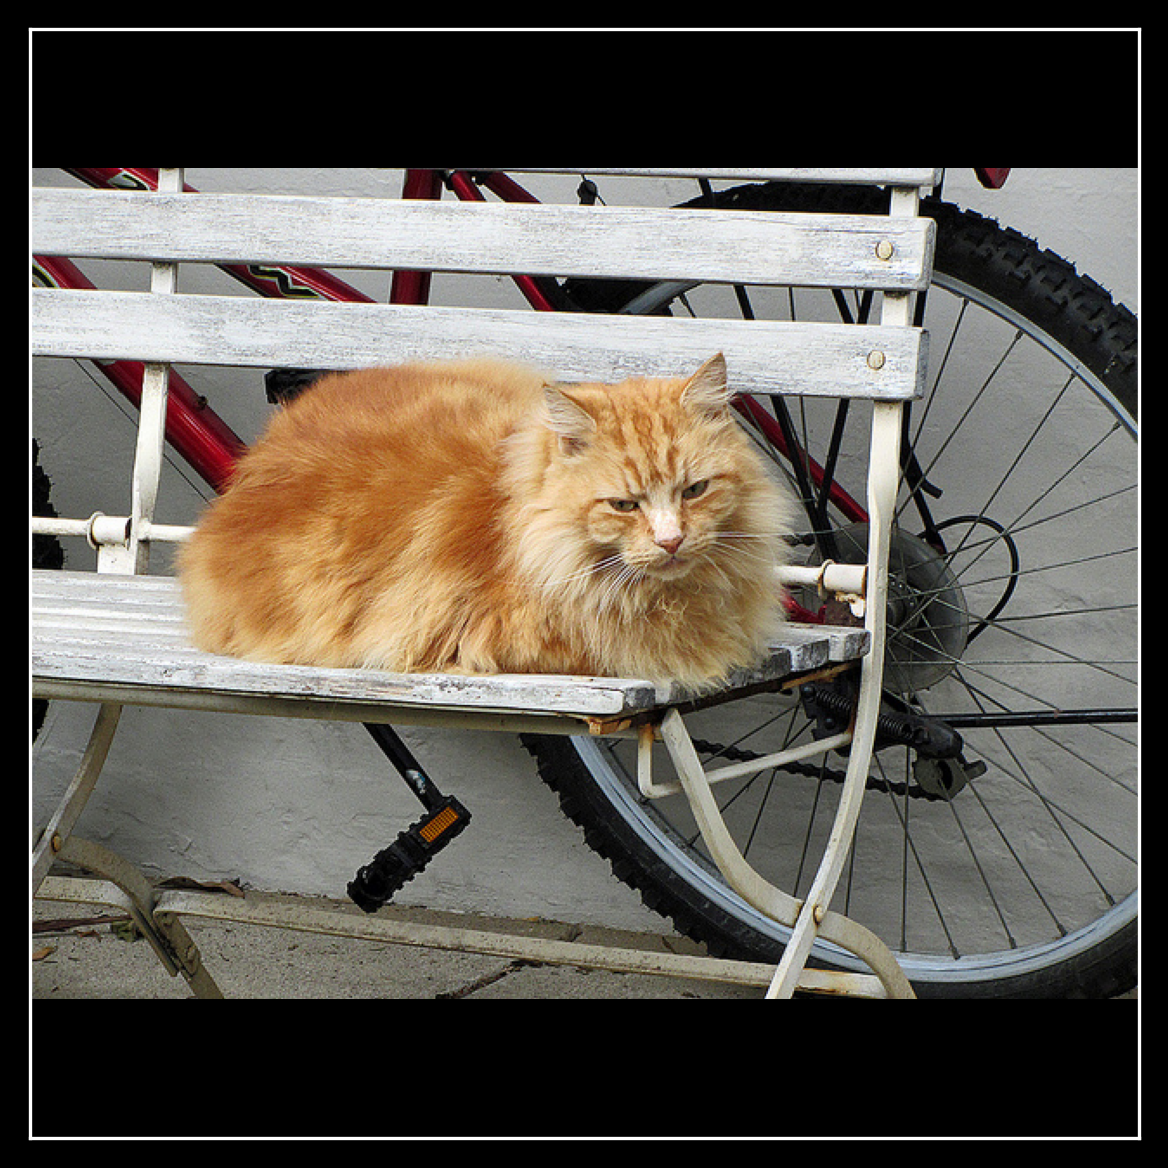

In [20]:
ig, ax = plt.subplots(dpi=300)
draw_image(ax, sample["path"])

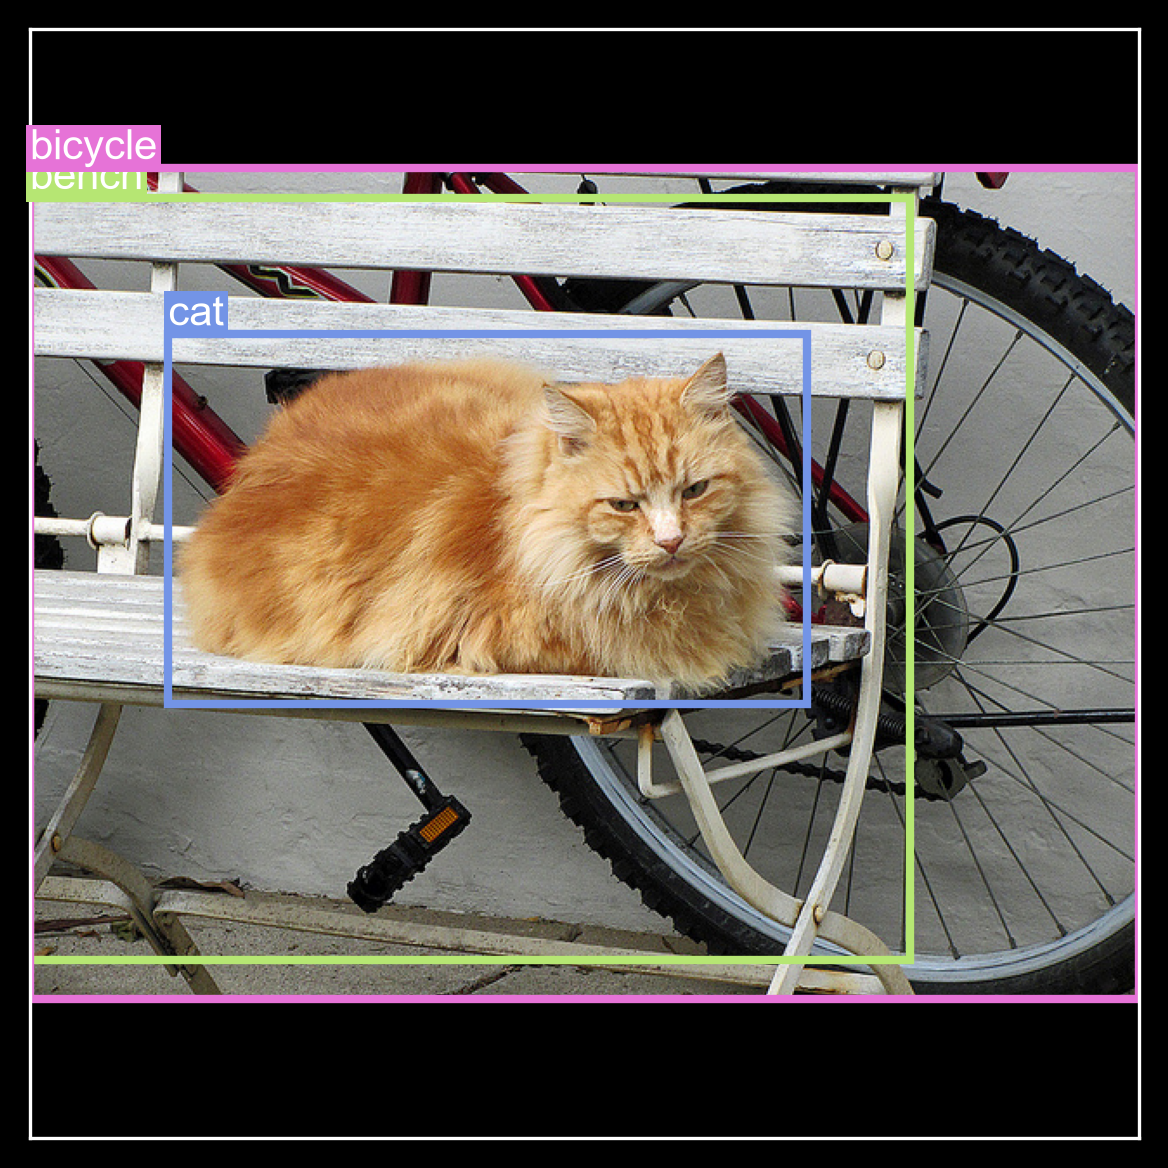

In [21]:
ig, ax = plt.subplots(dpi=300)
draw_image(ax, sample["path"])
for box, label in zip(sample["boxes"], sample["labels"]):
    label_name = keras_hub.utils.coco_id_to_name(label)
    draw_box(ax, box, label_name, label_to_color(label))
plt.show()

In [22]:
print("Before Trimming :", len(metadata))
metadata = list(filter(lambda x: len(x["boxes"]) <= 4, metadata))
random.shuffle(metadata)
print("After Trimming :", len(metadata))

Before Trimming : 117266
After Trimming : 59203


### Model

In [23]:
backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
backbone.summary()

Model: "res_net_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_co… │ (None, None,      │      4,096 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_bn  │ (None, None,      │        256 │ stack0_block0_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_re… │ (None, None,      │          0 │ stack0_block0_1_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_co… │ (None, None,      │     36,864 │ stack0_block0_1_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_bn  │ (None, None,      │        256 │ stack0_block0_2_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_re… │ (None, None,      │          0 │ stack0_block0_2_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_0_co… │ (None, None,      │     16,384 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_3_co… │ (None, None,      │     16,384 │ stack0_block0_2_… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_0_bn  │ (None, None,      │      1,024 │ stack0_block0_0_… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_3_bn  │ (None, None,      │      1,024 │ stack0_block0_3_

 Total params: 23,561,152 (89.88 MB)

 Trainable params: 23,508,032 (89.68 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [24]:
image_size = 448
# preprocessor = keras_hub.layers.ImageConverter.from_preset("resnet_50_imagenet",image_size=(image_size, image_size),)
preprocessor = keras.Sequential([
    keras.layers.Resizing(image_size, image_size, crop_to_aspect_ratio=True)
    # keras.layers.Rescaling(1.0 / 255.0)
])
grid_size = 6
num_labels = 91

In [25]:
inputs = keras.Input(shape=(image_size, image_size, 3))
x = backbone(inputs)
x = keras.layers.Conv2D(512, (3, 3), strides=(2, 2))(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(2048, activation="relu", kernel_initializer="glorot_normal")(x)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(grid_size * grid_size * (num_labels + 5))(x)
x = keras.layers.Reshape((grid_size, grid_size, num_labels + 5))(x)
box_predictions = x[..., :5]
class_predictions = keras.layers.Activation("softmax")(x[..., 5:])
outputs = {"box": box_predictions, "class": class_predictions}
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 448, 448,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_net_backbone    │ (None, 14, 14,    │ 23,561,152 │ input_layer_1[0]… │
│ (ResNetBackbone)    │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 6, 6, 512) │  9,437,696 │ res_net_backbone… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 18432)     │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2048)      │ 37,750,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3456)      │  7,081,344 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 6, 6, 96)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 6, 6, 91)  │          0 │ reshape[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 6, 6, 5)   │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 6, 6, 91)  │          0 │ get_item_1[0][0]  │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,830,976 (296.90 MB)

 Trainable params: 77,777,856 (296.70 MB)

 Non-trainable params: 53,120 (207.50 KB)

### Data Preprocess

In [26]:
def to_grid(box):
    x, y, w, h = box
    cx, cy = (x + w / 2) * grid_size, (y + h / 2) * grid_size
    ix, iy = int(cx), int(cy)
    return (ix, iy), (cx - ix, cy - iy, w, h)

def from_grid(loc, box):
    (xi, yi), (x, y, w, h) = loc, box
    x = (xi + x) / grid_size - w / 2
    y = (yi + y) / grid_size - h / 2
    return (x, y, w, h)

In [27]:
class_array = np.zeros((len(metadata), grid_size, grid_size))
box_array = np.zeros((len(metadata), grid_size, grid_size, 5))

for index, sample in enumerate(metadata):
    boxes, labels = sample["boxes"], sample["labels"]
    for box, label in zip(boxes, labels):
        (x, y, w, h) = box
        left, right = math.floor(x * grid_size), math.ceil((x + w) * grid_size)
        bottom, top = math.floor(y * grid_size), math.ceil((y + h) * grid_size)
        class_array[index, bottom:top, left:right] = label

for index, sample in enumerate(metadata):
    boxes, labels = sample["boxes"], sample["labels"]
    for box, label in zip(boxes, labels):
        (xi, yi), (grid_box) = to_grid(box)
        box_array[index, yi, xi] = [*grid_box, 1.0]
        class_array[index, yi, xi] = label

In [28]:
def draw_prediction(image, boxes, classes, cutoff=None):
    fig, ax = plt.subplots(dpi=300)
    draw_image(ax, image)
    for yi, row in enumerate(classes):
        for xi, label in enumerate(row):
            color = label_to_color(label) if label else "none"
            x, y, w, h = (v / grid_size for v in (xi, yi, 1.0, 1.0))
            r = Rectangle((x, y), w, h, lw=2, ec="black", fc=color, alpha=0.5)
            ax.add_patch(r)
    for yi, row in enumerate(boxes):
        for xi, box in enumerate(row):
            box, confidence = box[:4], box[4]
            if not cutoff or confidence >= cutoff:
                box = from_grid((xi, yi), box)
                label = classes[yi, xi]
                color = label_to_color(label)
                name = keras_hub.utils.coco_id_to_name(label)
                draw_box(ax, box, f"{name} {max(confidence, 0):.2f}", color)
    plt.show()

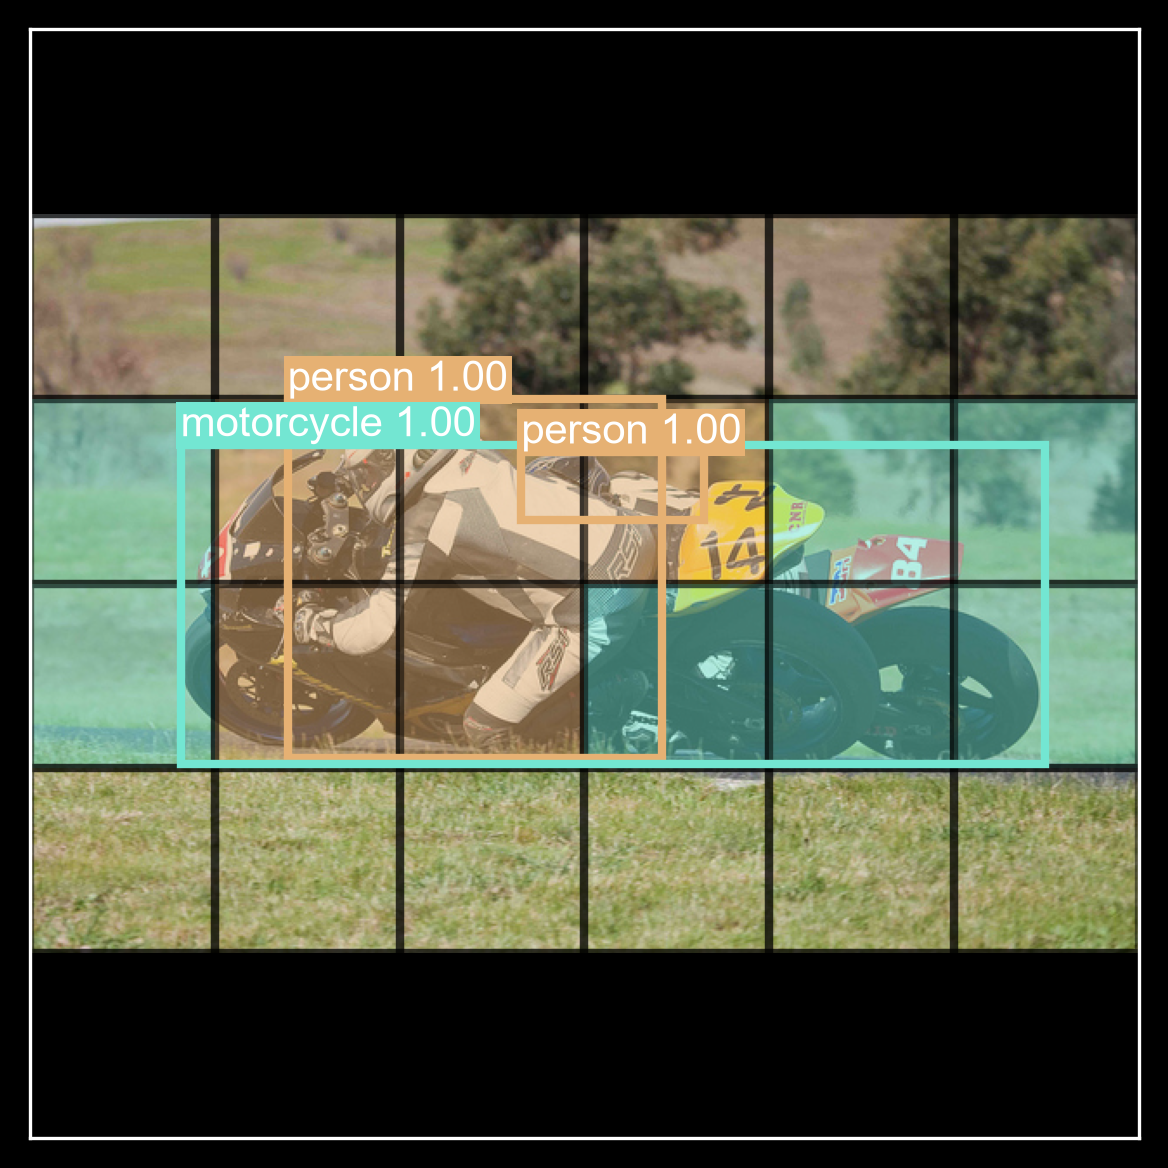

In [29]:
draw_prediction(metadata[0]["path"], box_array[0], class_array[0], cutoff=1.0)

In [30]:
def load_image(path):
    x = tf.io.read_file(path)
    x = tf.image.decode_jpeg(x, channels=3)
    return preprocessor(x)


images = tf.data.Dataset.from_tensor_slices([x["path"] for x in metadata])
images = images.map(load_image, num_parallel_calls=8)
labels = {"box": box_array, "class": class_array}
labels = tf.data.Dataset.from_tensor_slices(labels)
dataset = tf.data.Dataset.zip(images, labels).batch(16).prefetch(2)
val_dataset, train_dataset = dataset.take(500), dataset.skip(500)

NotImplementedError: in user code:

    File "C:\Users\PRASHANTH N\AppData\Local\Temp\ipykernel_14248\3059245094.py", line 4, in load_image  *
        return preprocessor(x)
    File "C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\gpu\.venv\Lib\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\gpu\.venv\Lib\site-packages\torch\utils\_pytree.py", line 1578, in tree_map
        return treespec.unflatten(map(func, *flat_args))
    File "C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\gpu\.venv\Lib\site-packages\torch\utils\_pytree.py", line 1313, in unflatten
        leaves = list(leaves)

    NotImplementedError: Cannot convert a symbolic tf.Tensor (DecodeJpeg:0) to a numpy array. This error may indicate that you're trying to pass a Tensor to a NumPy call, which is not supported.


### Model Custom Loss Function

In [ ]:
def unpack(box):
    return box[..., 0], box[..., 1], box[..., 2], box[..., 3]

def intersection(box1, box2):
    cx1, cy1, w1, h1 = unpack(box1)
    cx2, cy2, w2, h2 = unpack(box2)
    left = keras.ops.maximum(cx1 - w1 / 2, cx2 - w2 / 2)
    bottom = keras.ops.maximum(cy1 - h1 / 2, cy2 - h2 / 2)
    right = keras.ops.minimum(cx1 + w1 / 2, cx2 + w2 / 2)
    top = keras.ops.minimum(cy1 + h1 / 2, cy2 + h2 / 2)
    return keras.ops.maximum(0.0, right - left) * keras.ops.maximum(0.0, top - bottom)

def intersection_over_union(box1, box2):
    cx1, cy1, w1, h1 = unpack(box1)
    cx2, cy2, w2, h2 = unpack(box2)
    intersection_area = intersection(box1, box2)
    a1 = keras.ops.maximum(w1, 0.0) * keras.ops.maximum(h1, 0.0)
    a2 = keras.ops.maximum(w2, 0.0) * keras.ops.maximum(h2, 0.0)
    union_area = a1 + a2 - intersection_area
    return keras.ops.divide_no_nan(intersection_area, union_area)

In [ ]:
def signed_sqrt(x):
    return keras.ops.sign(x) * keras.ops.sqrt(keras.ops.absolute(x) + keras.config.epsilon())

def box_loss(true, pred):
    xy_true, wh_true, conf_true = true[..., :2], true[..., 2:4], true[..., 4:]
    xy_pred, wh_pred, conf_pred = pred[..., :2], pred[..., 2:4], pred[..., 4:]
    no_object = conf_true == 0.0
    xy_error = keras.ops.square(xy_true - xy_pred)
    wh_error = keras.ops.square(signed_sqrt(wh_true) - signed_sqrt(wh_pred))
    iou = intersection_over_union(true, pred)
    conf_target = keras.ops.where(no_object, 0.0, keras.ops.expand_dims(iou, -1))
    conf_error = keras.ops.square(conf_target - conf_pred)
    error = keras.ops.concatenate(
        (
            keras.ops.where(no_object, 0.0, xy_error * 5.0),
            keras.ops.where(no_object, 0.0, wh_error * 5.0),
            keras.ops.where(no_object, conf_error * 0.5, conf_error),
        ),
        axis=-1,
    )
    return keras.ops.sum(error, axis=(1, 2, 3))

### Model Training

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(2e-4),
    loss={"box": box_loss, "class": "sparse_categorical_crossentropy"},
)

In [ ]:
model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=4,
)

### Model Evaluation

In [ ]:
x, y = next(iter(val_dataset.rebatch(1)))
preds = model.predict(x)
boxes = preds["box"][0]
classes = np.argmax(preds["class"][0], axis=-1)
path = metadata[0]["path"]
draw_prediction(path, boxes, classes, cutoff=0.1)

In [ ]:
draw_prediction(path, boxes, classes, cutoff=None)